In [ ]:
#代码示例：3-1 —— 标量（0维数组）
import numpy as np          # 导入 NumPy 库，用于数值计算，简写为 np
x = np.array(888)           # 将数字 888 转为 NumPy 数组（只有一个数，没有维度）
print(x)                    # 输出数组的值：888
x.ndim                      # 查看维度数，结果为 0，说明这是一个"标量"

888


0

In [ ]:
#代码示例：3-2 —— 向量（1维数组）
x = np.array([1,2,3,4,5])   # 将一个列表转为 NumPy 数组，包含 5 个元素
print(x)                    # 输出：[1 2 3 4 5]
x.ndim                      # 结果为 1，说明这是一个"向量"（一维数组）

[1 2 3 4 5]


1

In [ ]:
#代码示例：3-3 —— 矩阵（2维数组）
x = np.array([[1,2,3,4],    # 第 1 行
              [5,6,7,8],    # 第 2 行
              [9,6,7,4]])   # 第 3 行 → 共 3 行 4 列的矩阵
print(x)
x.ndim                      # 结果为 2，说明这是一个"矩阵"（二维数组）

[[1 2 3 4]
 [5 6 7 8]
 [9 6 7 4]]


2

In [ ]:
#代码示例：3-4 —— 三维数组（张量）
# 深度学习中，图片、视频等数据通常是 3 维或更高维的数组（称为"张量"）
x = np.array([[[12,4,6,8,23],    # 第 1 块、第 1 行
               [45,1,2,6,67]],   # 第 1 块、第 2 行
              [[32,7,3,5,14],    # 第 2 块、第 1 行
               [56,1,2,8,18]],   # 第 2 块、第 2 行
              [[23,7,2,5,78],    # 第 3 块、第 1 行
               [14,2,7,2,15]]])  # 第 3 块、第 2 行 → 形状为 (3, 2, 5)
print(x)
x.ndim                           # 结果为 3，说明这是一个三维数组

[[[12  4  6  8 23]
  [45  1  2  6 67]]

 [[32  7  3  5 14]
  [56  1  2  8 18]]

 [[23  7  2  5 78]
  [14  2  7  2 15]]]


3

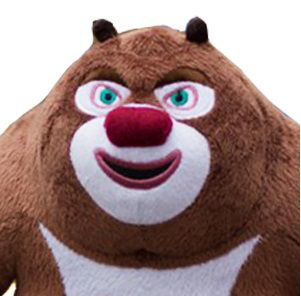

In [ ]:
#代码示例：3-5 —— 读取一张图片
from PIL import Image               # 从 Pillow 库导入 Image 模块，用于处理图片
photo = Image.open('./photos/xiongda.jpg')  # 打开指定路径的图片文件
photo                                # 在 notebook 中直接显示这张图片

(301, 296)
(128, 128)


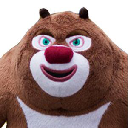

In [ ]:
#代码示例：3-6 —— 统一图片尺寸
print(photo.size)                    # 查看原始图片尺寸（宽, 高）
photo = photo.resize([128, 128])     # 将图片缩放为 128×128，统一大小
# ↑ 神经网络要求所有输入维度一致，所以必须把图片统一到相同尺寸
print(photo.size)                    # 确认缩放后的尺寸
photo                                # 显示缩放后的图片

In [ ]:
#代码示例：3-7 —— 将图片转为数组
import numpy as np
Im = np.array(photo)     # 把图片对象转成 NumPy 数组，每个像素用数字表示
print(Im.shape)          # 输出形状，例如 (128, 128, 3)
# ↑ 128×128 是图片的高和宽，3 表示 RGB 三个颜色通道（红、绿、蓝）
Im[:,:,0]                # 取出第 1 个通道（红色通道）的所有像素值

(128, 128, 3)


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [ 42,  36,  44, ...,  53,  57,  49],
       [ 33,  30, 152, ...,  52,  53,  48],
       [ 28, 150, 255, ...,  54,  50,  40]], dtype=uint8)

In [ ]:
#代码示例：3-8 —— 归一化：将像素值从 [0,255] 缩放到 [0,1]
Im = Im/255              # 除以 255，使像素值范围变为 0~1
# ↑ 归一化的好处：数值更小，有助于神经网络训练时梯度稳定、收敛更快
print(Im[:,:,0])         # 查看归一化后红色通道的像素值（现在都在 0~1 之间）

[[1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]
 ...
 [0.16470588 0.14117647 0.17254902 ... 0.20784314 0.22352941 0.19215686]
 [0.12941176 0.11764706 0.59607843 ... 0.20392157 0.20784314 0.18823529]
 [0.10980392 0.58823529 1.         ... 0.21176471 0.19607843 0.15686275]]


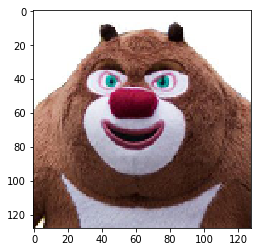

In [ ]:
#代码示例：3-9 —— 用 matplotlib 显示归一化后的图片
from matplotlib import pyplot as plt  # 导入绘图库
plt.imshow(Im);                       # 显示数组形式的图片（归一化后仍能正常显示）

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<Figure size 432x288 with 0 Axes>

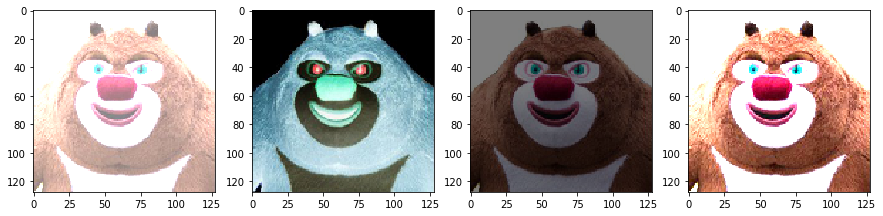

In [ ]:
#代码示例：3-10 —— 像素变换：观察不同数学运算对图像的影响
Im1=Im+0.5       # 整体加亮（像素值变大 → 图像变亮）
Im2=1-Im         # 反色（黑变白、白变黑）
Im3=0.5*Im       # 整体变暗（像素值缩小一半）
Im4=Im/0.5       # 亮度增强（像素值放大 2 倍）

plt.figure()
fig,ax=plt.subplots(1,4)     # 创建 1 行 4 列的子图
fig.set_figwidth(15)         # 设置总图宽度为 15 英寸
ax[0].imshow(Im1)            # 第 1 张：加亮的图
ax[1].imshow(Im2)            # 第 2 张：反色的图
ax[2].imshow(Im3)            # 第 3 张：变暗的图
ax[3].imshow(Im4)            # 第 4 张：增强亮度的图

In [ ]:
#代码示例：3-11 —— 读取 CSV 表格数据
import pandas as pd                         # 导入 Pandas 库，专门处理表格数据
MasterFile=pd.read_csv('./FoodScore.csv')    # 读取食物评分数据集 CSV 文件
print(MasterFile.shape)                      # 输出表格的行数和列数，如 (155, 2) 表示 155 行 2 列
MasterFile[0:5]                              # 显示前 5 行数据（包含 ID 和 score 两列）

(196, 2)


,ID,score
0,pic1,2.750333
1,pic2,2.962092
2,pic3,3.459351
3,pic4,2.246845
4,pic5,2.609172


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fe00868d080>]],
      dtype=object)

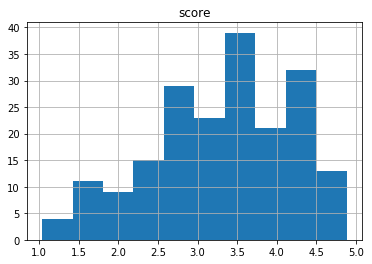

In [ ]:
#代码示例：3-12 —— 查看数据分布
MasterFile.hist()    # 对表格中所有数值列画直方图，直观了解数据分布情况

In [ ]:
#代码示例：3-13 —— 提取文件名和标签
import numpy as np
FileNames=MasterFile['ID']                            # 取出 ID 列 → 每个 ID 对应一张食物图片的文件名
N=len(FileNames)                                      # 统计总共有多少张图片
Y=np.array(MasterFile['score']).reshape([N,1])         # 取出 score 列作为标签 Y，reshape 为 (N,1) 列向量
# ↑ Y 就是我们要预测的目标值（食物吸引力评分）
#Y=(Y-np.mean(Y))/np.std(Y)                           # （可选）标准化：减均值除标准差，能加速训练收敛

In [ ]:
#代码示例：3-14 —— 批量读取所有食物图片
from PIL import Image

IMSIZE=128                                  # 统一图片大小为 128×128
X=np.zeros([N,IMSIZE,IMSIZE,3])             # 创建全零数组，形状为 (N, 128, 128, 3)
# ↑ N 张图片，每张 128×128 像素，3 个颜色通道（RGB）

for i in range(N):                          # 遍历每一张图片
    MyFile=FileNames[i]                     # 获取第 i 张图片的文件名
    Im=Image.open('./data_foodscore/'+MyFile+'.jpg')  # 打开图片
    Im=Im.resize([IMSIZE,IMSIZE])           # 缩放到 128×128
    Im=np.array(Im)/255                     # 转数组并归一化到 [0,1]
    X[i,]=Im                               # 存入总数组 X 的第 i 个位置
# 最终 X 的形状为 (N, 128, 128, 3)，包含了所有食物图片的像素数据

<Figure size 432x288 with 0 Axes>

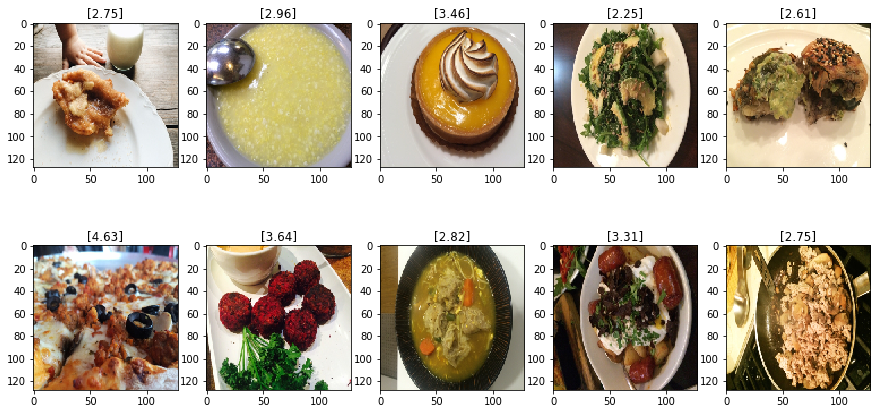

In [ ]:
#代码示例：3-15 —— 显示前 10 张图片及其评分
from matplotlib import pyplot as plt
plt.figure()
fig,ax=plt.subplots(2,5)          # 创建 2 行 5 列共 10 个子图
fig.set_figheight(7.5)
fig.set_figwidth(15)
ax=ax.flatten()                   # 将 2×5 的子图数组展平为一维，方便用下标访问
for i in range(10):
    ax[i].imshow(X[i,:,:,:])      # 显示第 i 张图片
    ax[i].set_title(np.round(Y[i],2))  # 标题显示该图片的评分（保留 2 位小数）
# ↑ 目的是检查图片与评分标签是否正确对应

In [ ]:
#代码示例：3-16 —— 划分训练集和测试集
from sklearn.cross_validation import train_test_split
# ↑ 注意：新版 sklearn 应改用 from sklearn.model_selection import train_test_split

X0,X1,Y0,Y1=train_test_split(X,Y,test_size=0.5,random_state=0)
# X0, Y0 → 训练集（用来训练模型的数据和标签）
# X1, Y1 → 测试集（用来评估模型效果的数据和标签）
# test_size=0.5 → 50% 的数据用于测试（实际项目中通常用 20%）
# random_state=0 → 固定随机种子，保证每次划分结果一致，方便复现

/home/clubear/anaconda3/lib/python3.6/site-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


In [ ]:
#代码示例：3-17 —— 构建食物评分回归模型（模型 1）
# ============================================================
# 这是一个最简单的神经网络，本质上等价于"线性回归"
# 目标：输入一张食物图片 → 输出一个评分预测值
# ============================================================
from keras.layers import Dense, Flatten, Input
from keras import Model

# 第 1 步：定义输入层 —— 告诉模型输入数据的形状
input_layer=Input([IMSIZE,IMSIZE,3])   # 输入是 128×128×3 的彩色图片

x=input_layer

# 第 2 步：Flatten 层 —— 将三维图片数据"拉平"成一维向量
x=Flatten()(x)
# ↑ 把 (128, 128, 3) 展平为长度 128×128×3 = 49152 的一维向量
# 因为全连接层 Dense 只能接收一维输入

# 第 3 步：Dense 层（全连接层）—— 核心计算层
x=Dense(1)(x)
# ↑ Dense(1) 表示输出 1 个数值（回归任务只需要输出一个预测值）
# 这一层做的计算是：output = w1*x1 + w2*x2 + ... + w49152*x49152 + b
# 即每个像素乘以一个权重，再加上偏置项，就是线性回归公式

output_layer=x

# 第 4 步：用 Model 把输入和输出连起来，构成完整的模型
model=Model(input_layer,output_layer)

# 打印模型结构：可以看到每层的形状和参数量
model.summary()
# ↑ Total params 约 49153 = 49152 个权重 + 1 个偏置

/home/clubear/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 128, 128, 3)       0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 49152)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 49153     
Total params: 49,153
Trainable params: 49,153
Non-trainable params: 0
_________________________________________________________________


In [ ]:
#代码示例：3-18 —— 编译模型（配置训练方式）
from keras.optimizers import Adam

model.compile(
    loss='mse',               # 损失函数：MSE（均方误差）= 预测值与真实值差的平方的平均
                              # ↑ 数值越小说明预测越准确，回归任务最常用的损失函数
    optimizer=Adam(lr=0.001), # 优化器：Adam —— 一种自动调整学习步长的梯度下降算法
                              # lr=0.001 是学习率，控制每次更新权重的幅度
                              # 太大会导致训练不稳定，太小会导致训练很慢
    metrics=['mse']           # 评价指标：训练过程中额外显示 MSE 值
)
# ↑ compile 不会开始训练，只是告诉模型"怎么算误差"和"怎么更新权重"

In [ ]:
#代码示例：3-19 —— 训练模型（模型 1：食物评分回归）
model.fit(
    X0, Y0,                    # 训练数据：X0 是图片，Y0 是对应的评分标签
    validation_data=[X1,Y1],   # 验证数据：每轮训练结束后，用这组数据评估模型表现
                               # ↑ 验证集不参与训练，用来检测模型是否"过拟合"
    batch_size=100,            # 每批次送入 100 张图片进行一次权重更新
                               # ↑ 不是一次性把所有图片都送进去，而是分批次处理
    epochs=100                 # 训练 100 轮（所有数据完整过一遍算 1 轮）
                               # ↑ 训练过程中会看到 loss 逐渐下降，说明模型在学习
)
# 训练完成后，模型内部的权重 w 和偏置 b 已经被优化过了

#代码示例：3-20 —— 用训练好的模型预测新图片的评分
MyPic=Image.open('mypic.jpg')              # 打开一张新的食物图片
MyPic
MyPic=MyPic.resize((IMSIZE,IMSIZE))        # 缩放到和训练数据一样的 128×128
MyPic=np.array(MyPic)/255                  # 转数组并归一化（和训练时的预处理保持一致！）
MyPic=MyPic.reshape((1,IMSIZE,IMSIZE,3))   # 加一个维度变成 (1,128,128,3)
# ↑ 模型期望输入是"一批图片"，所以即使只有 1 张也要加上 batch 维度
model.predict(MyPic)                       # 输出预测的食物评分

Train on 98 samples, validate on 98 samples
Epoch 1/100
98/98 [==============================] - 2s 19ms/step - loss: 7.6803 - mean_squared_error: 7.6803 - val_loss: 241.7841 - val_mean_squared_error: 241.7841
Epoch 2/100
98/98 [==============================] - 0s 790us/step - loss: 253.3330 - mean_squared_error: 253.3330 - val_loss: 7.9680 - val_mean_squared_error: 7.9680
Epoch 3/100
98/98 [==============================] - 0s 773us/step - loss: 7.7044 - mean_squared_error: 7.7044 - val_loss: 105.5857 - val_mean_squared_error: 105.5857
Epoch 4/100
98/98 [==============================] - 0s 773us/step - loss: 112.2314 - mean_squared_error: 112.2314 - val_loss: 147.1404 - val_mean_squared_error: 147.1404
Epoch 5/100
98/98 [==============================] - 0s 782us/step - loss: 156.2819 - mean_squared_error: 156.2819 - val_loss: 45.7204 - val_mean_squared_error: 45.7204
Epoch 6/100
98/98 [==============================] - 0s 789us/step - loss: 48.5066 - mean_squared_error: 48.5066 - v

Epoch 51/100
98/98 [==============================] - 0s 777us/step - loss: 0.8157 - mean_squared_error: 0.8157 - val_loss: 1.3594 - val_mean_squared_error: 1.3594
Epoch 52/100
98/98 [==============================] - 0s 789us/step - loss: 0.6487 - mean_squared_error: 0.6487 - val_loss: 2.0039 - val_mean_squared_error: 2.0039
Epoch 53/100
98/98 [==============================] - 0s 777us/step - loss: 1.3666 - mean_squared_error: 1.3666 - val_loss: 2.0573 - val_mean_squared_error: 2.0573
Epoch 54/100
98/98 [==============================] - 0s 794us/step - loss: 1.4212 - mean_squared_error: 1.4212 - val_loss: 1.4378 - val_mean_squared_error: 1.4378
Epoch 55/100
98/98 [==============================] - 0s 789us/step - loss: 0.7239 - mean_squared_error: 0.7239 - val_loss: 1.3470 - val_mean_squared_error: 1.3470
Epoch 56/100
98/98 [==============================] - 0s 803us/step - loss: 0.5663 - mean_squared_error: 0.5663 - val_loss: 1.8494 - val_mean_squared_error: 1.8494
Epoch 57/100
98/

FileNotFoundError: [Errno 2] No such file or directory: 'mypic.jpg'

In [ ]:
#代码示例：3-20（重复） —— 用训练好的模型预测新图片的评分
MyPic=Image.open('mypic.jpg')              # 打开新图片
MyPic
MyPic=MyPic.resize((IMSIZE,IMSIZE))        # 缩放为 128×128
MyPic=np.array(MyPic)/255                  # 转数组 + 归一化
MyPic=MyPic.reshape((1,IMSIZE,IMSIZE,3))   # 增加 batch 维度
model.predict(MyPic)                       # 模型输出预测评分

array([[3.2026231]], dtype=float32)

In [ ]:
#代码示例：3-21 —— 读取 MNIST 手写数字数据集
# ============================================================
# MNIST 是机器学习最经典的入门数据集，包含 0~9 的手写数字图片
# 每张图片是 28×28 像素的灰度图（只有黑白，没有颜色）
# ============================================================

# 旧写法（TensorFlow 1.x 教程接口，现版本通常已废弃）
# from tensorflow.examples.tutorials.mnist import input_data
# data = input_data.read_data_sets("data/MNIST/",one_hot=False)

from types import SimpleNamespace
from tensorflow.keras.datasets import mnist

# 自动下载并加载 MNIST 数据集
(X_train_full, Y_train_full), (X_test, Y_test) = mnist.load_data()

# 将图片从 28×28 的二维矩阵 → 展平为长度 784 的一维向量
X_train_full = X_train_full.reshape(-1, 28 * 28).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28 * 28).astype("float32") / 255.0
# ↑ reshape(-1, 784)：-1 表示自动计算样本数，784 = 28×28
# ↑ /255.0：归一化像素值到 [0,1]

# 从训练集中划分出 5000 张作为验证集
X_train = X_train_full[:-5000]          # 前 55000 张用于训练
Y_train = Y_train_full[:-5000]
X_validation = X_train_full[-5000:]     # 最后 5000 张用于验证
Y_validation = Y_train_full[-5000:]

# 将数据封装成统一结构，方便后续代码调用
data = SimpleNamespace(
    train=SimpleNamespace(images=X_train, labels=Y_train),
    validation=SimpleNamespace(images=X_validation, labels=Y_validation),
    test=SimpleNamespace(images=X_test, labels=Y_test),
)

2026-03-16 21:13:16.124016: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 21:13:16.665850: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 21:13:18.566280: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#代码示例：3-22 —— 取出训练集和验证集
X0 = data.train.images          # 训练集图片，形状 (55000, 784)
Y0 = data.train.labels          # 训练集标签，每个值是 0~9 的整数
X1 = data.validation.images     # 验证集图片，形状 (5000, 784)
Y1 = data.validation.labels     # 验证集标签
print(X0.shape)                 # 查看训练集形状：(55000, 784)
# ↑ 55000 张图片，每张展平为 784 维向量

(55000, 784)


<Figure size 640x480 with 0 Axes>

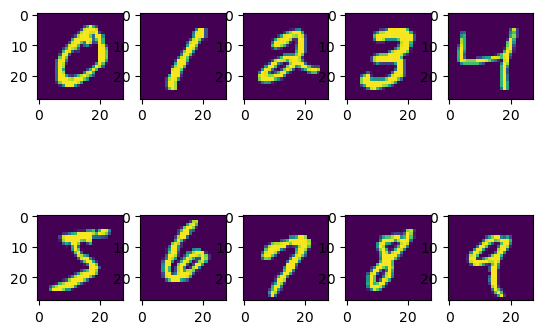

In [ ]:
#代码示例：3-23 —— 可视化每个数字的样本
from matplotlib import pyplot as plt
plt.figure()
fig,ax = plt.subplots(2,5)       # 创建 2 行 5 列共 10 个子图（对应数字 0~9）
ax=ax.flatten()
for i in range(10):
    Im=X0[Y0==i][0].reshape(28,28)  # 找到标签为 i 的第一张图片，恢复为 28×28
    # ↑ Y0==i 返回所有标签等于 i 的布尔索引，[0] 取第一张
    ax[i].imshow(Im)                # 显示该图片
plt.show()

In [ ]:
#代码示例：3-24 —— One-Hot 编码（独热编码）
Y0    # 原始标签，例如 [5, 0, 4, 1, 9, ...]（每个是一个整数）

from keras.utils import to_categorical 
YY0=to_categorical(Y0)   # 将整数标签转为 one-hot 编码
YY1=to_categorical(Y1)
YY1
# ↑ One-Hot 编码示例：
#   数字 0 → [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
#   数字 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
#   数字 9 → [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
# 这样做是因为分类模型的输出是 10 个概率值，需要标签也是 10 维的向量来计算损失

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(5000, 10))

In [ ]:
#代码示例：3-25 —— 构建 MNIST 分类模型（模型 2）
# ============================================================
# 这是一个 Softmax 分类器，本质等价于"多类逻辑回归"
# 目标：输入一张手写数字图片 → 输出它属于 0~9 哪个数字的概率
# ============================================================
from keras.layers import Activation, Dense, Flatten, Input
from keras import Model

# 第 1 步：定义输入层
input_shape=(784,)              # 输入是长度为 784 的一维向量（28×28 展平后）
input_layer=Input(input_shape)
x=input_layer

# 第 2 步：全连接层 —— 将 784 维输入映射到 10 个输出
x=Dense(10)(x)
# ↑ Dense(10) 表示有 10 个神经元（对应 0~9 共 10 个数字类别）
# 内部计算：对每个类别 k，算出一个分数 score_k = w_k · x + b_k
# 其中 w_k 是长度 784 的权重向量（相当于一个"模板"）

# 第 3 步：Softmax 激活 —— 将分数转换为概率
x=Activation('softmax')(x)
# ↑ Softmax 公式：P(k) = e^(score_k) / Σ e^(score_j)
# 保证 10 个输出值都在 0~1 之间，且加起来等于 1
# 例如输出 [0.01, 0.01, 0.05, 0.80, 0.02, ...] 表示最可能是数字 3

output_layer=x
model=Model(input_layer,output_layer)
# ↑ 这个模型没有隐藏层，是最简单的分类器之一

I0000 00:00:1773666875.672740   19226 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
#代码示例：3-26 —— 编译模型（配置训练方式）
from keras.optimizers import Adam

model.compile(
    optimizer = Adam(0.01),    # 优化器：Adam，学习率设为 0.01
                               # ↑ 学习率比模型 1 大 10 倍，因为 MNIST 数据量更大、更容易训练
    loss = 'categorical_crossentropy',  # 损失函数：交叉熵
                               # ↑ 分类任务专用的损失函数（回归用 MSE，分类用交叉熵）
                               # 它衡量"模型预测的概率分布"和"真实标签"之间的差距
    metrics = ['accuracy']     # 评价指标：准确率（预测对的比例）
                               # ↑ 方便训练时直观看到模型识别了多少图片
)

In [ ]:
#代码示例：3-27 —— 训练模型（模型 2：MNIST 手写数字分类）
model.fit(
    X0, YY0,                    # 训练数据：X0 是图片(784 维向量)，YY0 是 one-hot 标签
    validation_data=(X1,YY1),   # 验证数据：每轮结束后用来评估模型
                                # ↑ 观察 val_accuracy：如果训练准确率很高但验证准确率低，说明"过拟合"
    batch_size=1000,            # 每批次 1000 张图片（MNIST 共 55000 张，每轮约 55 个批次）
    epochs=10                   # 训练 10 轮
                                # ↑ 每轮的含义：所有 55000 张训练图片都被模型"看过"一遍
)
# 训练完成后，可以观察输出中的 accuracy 和 val_accuracy
# accuracy → 训练集准确率，val_accuracy → 验证集准确率
# 这个简单模型在 MNIST 上的准确率通常在 92% 左右

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9329 - loss: 0.2411 - val_accuracy: 0.9406 - val_loss: 0.2174
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9325 - loss: 0.2422 - val_accuracy: 0.9396 - val_loss: 0.2232
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9328 - loss: 0.2423 - val_accuracy: 0.9422 - val_loss: 0.2243
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9327 - loss: 0.2404 - val_accuracy: 0.9414 - val_loss: 0.2190
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9331 - loss: 0.2395 - val_accuracy: 0.9424 - val_loss: 0.2200
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9321 - loss: 0.2404 - val_accuracy: 0.9398 - val_loss: 0.2207
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9329 - loss: 0.2395 - val_accuracy: 0.9412 - val_loss: 0.2238
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9338 - loss: 0.2383 - val_accuracy: 0.9412 - val_loss:

In [ ]:
#代码示例：3-28 —— 查看模型的所有层
model.layers
# ↑ 返回一个列表，包含模型中的每一层
# layers[0] 是输入层，layers[1] 是 Dense 层，layers[2] 是 Softmax 层

[<InputLayer name=input_layer, built=True>,
 <Dense name=dense, built=True>,
 <Activation name=activation, built=True>]

In [ ]:
#代码示例：3-29 —— 查看 Dense 层学到的权重
model.layers[1].get_weights()
# ↑ 返回一个列表 [权重矩阵 W, 偏置向量 b]
# W 的形状是 (784, 10)：784 个输入 × 10 个输出
# b 的形状是 (10,)：每个类别一个偏置值

[array([[ 0.01054343, -0.00142239,  0.04771226, ...,  0.03768414,
          0.05415695,  0.07184929],
        [ 0.05529497, -0.07945248,  0.03213036, ...,  0.00672094,
          0.04839361, -0.01111035],
        [-0.05421117, -0.00214689, -0.01648402, ...,  0.04307201,
         -0.04402538, -0.03492872],
        ...,
        [-0.02803966, -0.01359839, -0.04126377, ...,  0.08327033,
         -0.0542316 , -0.0307796 ],
        [ 0.00901666,  0.0431743 ,  0.04569381, ..., -0.03364173,
          0.01520652,  0.01448523],
        [ 0.05492363, -0.01283643, -0.06918954, ..., -0.07747969,
         -0.01752461,  0.00382361]], shape=(784, 10), dtype=float32),
 array([-0.31534818,  0.46733376,  0.06048451, -0.52218634,  0.1769277 ,
         1.4228147 , -0.19988379,  0.68770236, -1.4167814 , -0.40206435],
       dtype=float32)]

In [ ]:
#代码示例：3-30 —— 查看权重矩阵的形状
model.layers[1].get_weights()[0].shape
# ↑ 结果是 (784, 10)，表示有 784×10 = 7840 个权重参数
# 每一列（784 个值）对应一个数字的"模板权重"

(784, 10)

<Figure size 640x480 with 0 Axes>

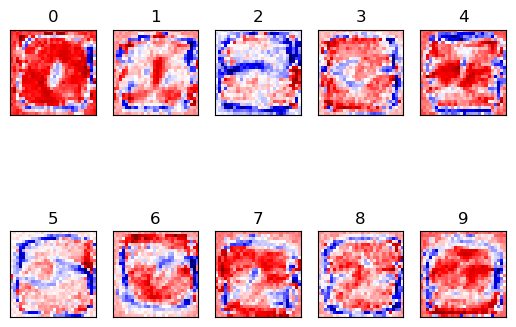

In [ ]:
#代码示例：3-31 —— 可视化模型学到的权重（直观理解线性分类器）
plt.figure()
fig,ax = plt.subplots(2,5)       # 2 行 5 列 = 10 个子图，对应数字 0~9
ax=ax.flatten()
weights = model.layers[1].get_weights()[0]   # 取出权重矩阵，形状 (784, 10)

for i in range(10):
    Im=weights[:,i].reshape((28,28))  # 取第 i 列（784 维）→ 恢复为 28×28 图像
    ax[i].imshow(Im,cmap='seismic')   # 用红蓝色图显示：红色=正权重，蓝色=负权重
    ax[i].set_title("{}".format(i))   # 标题显示数字
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.show()
# ↑ 这 10 张图展示了模型"学到"的每个数字的模板
# 分类时，模型计算输入图片和每个模板的"相似度"，最相似的那个就是预测结果
# 这就是线性分类器的本质：通过模板匹配来完成分类